In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
Nx = 20
Ny = 20
Re = 10
u_lid = 0.005
n_iterations = 100
export_frequency = 1

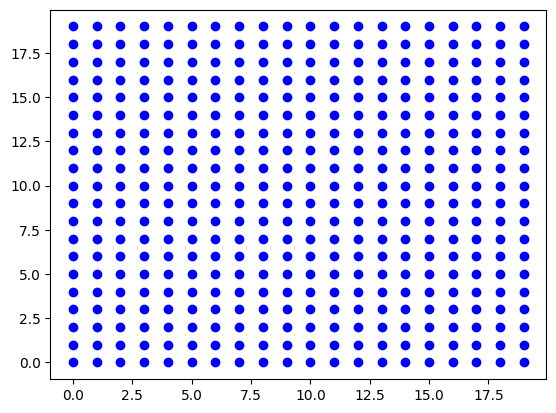

(20, 20)

In [3]:
x = np.arange(0, Nx, 1)
y = np.arange(0, Ny, 1)

X, Y = np.meshgrid(x, y)

plt.plot(X, Y, linestyle="none", marker="o", c="blue")
plt.show()

X.shape

In [4]:
# Velocity set: ei, cs
# D2Q9
cs = 1 / 3**0.5

D2Q9 = {
    "e0": {"direction": [0, 0, 0], "weight": 16 / 36},
    "e1": {"direction": [1, 0, 0], "weight": 4 / 36},
    "e2": {"direction": [0, 1, 0], "weight": 4 / 36},
    "e3": {"direction": [-1, 0, 0], "weight": 4 / 36},
    "e4": {"direction": [0, -1, 0], "weight": 4 / 36},
    "e5": {"direction": [1, 1, 0], "weight": 1 / 36},
    "e6": {"direction": [-1, 1, 0], "weight": 1 / 36},
    "e7": {"direction": [-1, -1, 0], "weight": 1 / 36},
    "e8": {"direction": [1, -1, 0], "weight": 1 / 36},
}

e = np.array([D2Q9[direc]["direction"][:2] for direc in D2Q9.keys()])
w = np.array([D2Q9[direc]["weight"] for direc in D2Q9.keys()])
vel_set_components = len(D2Q9.keys())

In [5]:
viscosity = u_lid * Nx / Re
tau = 1 / 2 + viscosity / (cs**2)

In [6]:
import pyvista as pv
import pathlib


def export_macros(ux, uy, rho, timestep, nodes_x, nodes_y):
    z = np.zeros_like(nodes_y)
    grid = pv.StructuredGrid(nodes_x, nodes_y, z, force_float=False)
    grid.point_data["rho"] = rho.ravel()
    grid.point_data["ux"] = ux.ravel()
    grid.point_data["uy"] = uy.ravel()
    output_filename = pathlib.Path("./cases") / f"macros_{timestep:07d}.vts"
    grid.save(output_filename, binary=False)


def export_population(timestep, nodes_x, nodes_y, f):
    z = np.zeros_like(nodes_y)
    grid = pv.StructuredGrid(nodes_x, nodes_y, z, force_float=False)
    for i in range(f.shape[2]):
        grid.point_data[f"f{i}"] = f[:, :, i].ravel()
    output_filename = pathlib.Path("./cases") / f"population_{timestep:07d}.vts"
    grid.save(output_filename, binary=False)

In [7]:
def equilibrium_pop(rho, ux, uy):
    H_0 = 1
    H_1 = (e[:, 0] * ux[:, :, np.newaxis] + e[:, 1] * uy[:, :, np.newaxis]) / cs**2
    H_2 = (9 / 2) * (
        ux[:, :, np.newaxis] ** 2 * (e[:, 0] ** 2 - 1)
        + ux[:, :, np.newaxis] * uy[:, :, np.newaxis] * (e[:, 0] * e[:, 1])
        + uy[:, :, np.newaxis] ** 2 * (e[:, 1] ** 2 - 1)
    )
    f_eq = w * rho[:, :, np.newaxis] * (H_0 + H_1 + H_2)
    return f_eq


ux = np.zeros((Nx, Ny))
uy = np.zeros((Nx, Ny))
rho = np.ones((Nx, Ny))

f = np.ones((Nx, Ny, vel_set_components), dtype=np.float32)
f = equilibrium_pop(rho, ux, uy)

In [8]:
# Main loop - simulação
export_macros(ux, uy, rho, 0, X, Y)
export_population(0, X, Y, f)
for n_iter in range(n_iterations):
    # Streaming step
    f[:, :, 0] = f[:, :, 0]
    f[:, :, 1] = np.roll(f[:, :, 1], 1, axis=0)
    f[:, :, 2] = np.roll(f[:, :, 2], 1, axis=1)
    f[:, :, 3] = np.roll(f[:, :, 3], -1, axis=0)
    f[:, :, 4] = np.roll(f[:, :, 4], -1, axis=1)
    f[:, :, 5] = np.roll((np.roll(f[:, :, 5], 1, axis=0)), 1, axis=1)
    f[:, :, 6] = np.roll((np.roll(f[:, :, 6], -1, axis=0)), 1, axis=1)
    f[:, :, 7] = np.roll((np.roll(f[:, :, 7], -1, axis=0)), -1, axis=1)
    f[:, :, 8] = np.roll((np.roll(f[:, :, 8], 1, axis=0)), -1, axis=1)

    # Boundary conditions
    f[0, :, [1, 5, 8]] = f[0, :, [3, 7, 6]]  # esquerda
    f[Nx - 1, :, [3, 7, 6]] = f[Nx - 1, :, [1, 5, 8]]  # direita
    f[:, 0, [2, 5, 6]] = f[:, 0, [4, 7, 8]]  # baixo

    # f[:, Ny - 1, :]  # cima
    rho_wall = (
        f[:, Ny - 1, 0]
        + f[:, Ny - 1, 1]
        + f[:, Ny - 1, 3]
        + 2 * (f[:, Ny - 1, 2] + f[:, Ny - 1, 5] + f[:, Ny - 1, 6])
    )
    f[:, Ny - 1, 4] = f[:, Ny - 1, 2]
    f[:, Ny - 1, 7] = (
        f[:, Ny - 1, 5] + (f[:, Ny - 1, 1] - f[:, Ny - 1, 3]) / 2 - rho_wall * u_lid / 2
    )
    f[:, Ny - 1, 8] = (
        f[:, Ny - 1, 6] - (f[:, Ny - 1, 1] - f[:, Ny - 1, 3]) / 2 + rho_wall * u_lid / 2
    )
    rho = np.sum(f, axis=2)
    ux = (np.sum(f * e[:, 0], axis=2)) / rho
    uy = (np.sum(f * e[:, 1], axis=2)) / rho

    # Collision step
    feq = equilibrium_pop(rho, ux, uy)
    omega = (f - feq) / tau
    # Avanço temporal
    f = f + omega

    if n_iter % export_frequency == 0:
        export_macros(ux, uy, rho, n_iter, X, Y)
        export_population(n_iter, X, Y, f)
        print("Exported macros!")

    print(f"Iteration {n_iter} of {n_iterations}")


# MLUPS = Milhoes de updates de lattice por segundo
# Nx * Ny / (10e6 * t_final)

Exported macros!
Iteration 0 of 100
Exported macros!
Iteration 1 of 100
Exported macros!
Iteration 2 of 100
Exported macros!
Iteration 3 of 100
Exported macros!
Iteration 4 of 100
Exported macros!
Iteration 5 of 100
Exported macros!
Iteration 6 of 100
Exported macros!
Iteration 7 of 100
Exported macros!
Iteration 8 of 100
Exported macros!
Iteration 9 of 100
Exported macros!
Iteration 10 of 100
Exported macros!
Iteration 11 of 100
Exported macros!
Iteration 12 of 100
Exported macros!
Iteration 13 of 100
Exported macros!
Iteration 14 of 100
Exported macros!
Iteration 15 of 100
Exported macros!
Iteration 16 of 100
Exported macros!
Iteration 17 of 100
Exported macros!
Iteration 18 of 100
Exported macros!
Iteration 19 of 100
Exported macros!
Iteration 20 of 100
Exported macros!
Iteration 21 of 100
Exported macros!
Iteration 22 of 100
Exported macros!
Iteration 23 of 100
Exported macros!
Iteration 24 of 100
Exported macros!
Iteration 25 of 100
Exported macros!
Iteration 26 of 100
Exported ma